# Harassment Detection Pipeline
### Bangla | English | Banglish — Multilingual + Sentiment-Aware

**Pipeline Steps:**
1. Install and Import Libraries
2. Load Datasets
3. Explore Raw Data
4. Preprocessing
5. Visualization (one graph per cell)
6. Sentiment Feature Engineering
7. Model Training and Evaluation
8. Manual Comment Testing

--- 
## 1. Install and Import Libraries

In [1]:
# Install required packages (run once)
# transformers + torch: for multilingual BERT-based models (Bangla, English, Banglish)
# sahajBERT / bangla-bert will be loaded via HuggingFace hub at runtime
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost vaderSentiment textblob scipy transformers torch sentencepiece langdetect accelerate -q

In [2]:
import os
from huggingface_hub import login

# Set your HuggingFace token to avoid unauthenticated request warnings.
# Option 1: set as environment variable before running the notebook:
#   export HF_TOKEN="hf_your_token_here"
# Option 2: paste your token directly in the string below (do not share the notebook publicly if you do this).
# Get your free token at: https://huggingface.co/settings/tokens

HF_TOKEN = os.environ.get("HF_TOKEN", "")   # reads from env if set

if HF_TOKEN:
    login(token=HF_TOKEN, add_to_git_credential=False)
    print("HuggingFace Hub: authenticated.")
else:
    print("HuggingFace Hub: no token found. Downloads will work but may be slower.")
    print("  -> Set HF_TOKEN env variable or paste your token into HF_TOKEN above.")


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
import logging
warnings.filterwarnings('ignore')
logging.getLogger('huggingface_hub').setLevel(logging.ERROR)
logging.getLogger('transformers').setLevel(logging.ERROR)

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.preprocessing import MaxAbsScaler
from scipy.sparse import hstack, csr_matrix

from xgboost import XGBClassifier
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

# Transformer imports for Bangla-aware deep model
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from torch.utils.data import Dataset

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
print('All libraries loaded successfully.')

HuggingFace Hub: no token found. Downloads will work but may be slower.
  -> Set HF_TOKEN env variable or paste your token into HF_TOKEN above.
Device : cpu
All libraries loaded successfully.


---
## 2. Load Datasets

In [3]:
df_ba = pd.read_csv("https://raw.githubusercontent.com/NafisOfficial/Social-Media-Full-Project/refs/heads/main/Datasets/Bengali%20hate%20speech_updated.csv")
df_en = pd.read_csv("https://raw.githubusercontent.com/NafisOfficial/Social-Media-Full-Project/refs/heads/main/Datasets/toxic_comments_50000.csv")
df_bl = pd.read_csv("https://raw.githubusercontent.com/NafisOfficial/Social-Media-Full-Project/refs/heads/main/Datasets/toxic_comments_dataset_updated.csv")

df_ba['lang_source'] = 'bangla'
df_en['lang_source'] = 'english'
df_bl['lang_source'] = 'banglish'

print(f'Bangla   dataset: {df_ba.shape[0]:,} rows x {df_ba.shape[1]} cols')
print(f'English  dataset: {df_en.shape[0]:,} rows x {df_en.shape[1]} cols')
print(f'Banglish dataset: {df_bl.shape[0]:,} rows x {df_bl.shape[1]} cols')

Bangla   dataset: 30,000 rows x 8 cols
English  dataset: 49,998 rows x 8 cols
Banglish dataset: 49,998 rows x 8 cols


---
## 3. Explore Raw Data

In [4]:
print('=== BANGLA DATASET ===')
display(df_ba.head(5))
print(f'Columns : {list(df_ba.columns)}')
print(f'Nulls   :\n{df_ba.isnull().sum()}')
print(f"Label distribution:\n{df_ba['hate'].value_counts()}")

=== BANGLA DATASET ===


,sentence,hate,category,is_harassment,harassment_type,severity,confidence_score,lang_source
0,যত্তসব পাপন শালার ফাজলামী!!!!!,1,bangla,yes,bullying,5,0.84,bangla
1,পাপন শালা রে রিমান্ডে নেওয়া দরকার,1,bangla,yes,threat,3,0.98,bangla
2,জিল্লুর রহমান স্যারের ছেলে এতো বড় জারজ হবে এটা...,1,bangla,yes,threat,5,0.93,bangla
3,শালা লুচ্চা দেখতে পাঠার মত দেখা যায়,1,bangla,yes,bullying,5,0.89,bangla
4,তুই তো শালা গাজা খাইছচ।তুর মার হেডায় খেলবে সাকিব,1,bangla,yes,sexual_harassment,3,0.79,bangla


Columns : ['sentence', 'hate', 'category', 'is_harassment', 'harassment_type', 'severity', 'confidence_score', 'lang_source']
Nulls   :
sentence            0
hate                0
category            0
is_harassment       0
harassment_type     0
severity            0
confidence_score    0
lang_source         0
dtype: int64
Label distribution:
hate
0    20000
1    10000
Name: count, dtype: int64


In [5]:
print('=== ENGLISH DATASET ===')
display(df_en.head(5))
print(f'Columns : {list(df_en.columns)}')
print(f'Nulls   :\n{df_en.isnull().sum()}')
print(f"Label distribution:\n{df_en['hate'].value_counts()}")

=== ENGLISH DATASET ===


,sentence,hate,category,is_harassment,harassment_type,severity,confidence_score,lang_source
0,What nonsense is this,1,online_comment,yes,hate_speech,5,0.84,english
1,What nonsense is this 😂,1,online_comment,yes,hate_speech,3,0.98,english
2,This is so wtupid,1,online_comment,yes,hate_speech,5,0.93,english
3,You are useless,1,online_comment,yes,bullying,5,0.89,english
4,What nonsense is this,1,online_comment,yes,hate_speech,3,0.79,english


Columns : ['sentence', 'hate', 'category', 'is_harassment', 'harassment_type', 'severity', 'confidence_score', 'lang_source']
Nulls   :
sentence            0
hate                0
category            0
is_harassment       0
harassment_type     0
severity            0
confidence_score    0
lang_source         0
dtype: int64
Label distribution:
hate
0    33332
1    16666
Name: count, dtype: int64


In [6]:
print('=== BANGLISH DATASET ===')
display(df_bl.head(5))
print(f'Columns : {list(df_bl.columns)}')
print(f'Nulls   :\n{df_bl.isnull().sum()}')
print(f"Label distribution:\n{df_bl['hate'].value_counts()}")

=== BANGLISH DATASET ===


,sentence,hate,category,is_harassment,harassment_type,severity,confidence_score,lang_source
0,Tmi ki ba bujho 🤮,1,English,yes,hate_speech,5,0.84,banglish
1,Tmi ki ba bujho,1,English,yes,hate_speech,3,0.98,banglish
2,Tmi ki oa bujho... 😂,1,English,yes,hate_speech,5,0.93,banglish
3,Eta pura nonsense,1,Mixed,yes,hate_speech,5,0.89,banglish
4,Eta pura nonsense 😤,1,English,yes,hate_speech,3,0.79,banglish


Columns : ['sentence', 'hate', 'category', 'is_harassment', 'harassment_type', 'severity', 'confidence_score', 'lang_source']
Nulls   :
sentence            0
hate                0
category            0
is_harassment       0
harassment_type     0
severity            0
confidence_score    0
lang_source         0
dtype: int64
Label distribution:
hate
0    33332
1    16666
Name: count, dtype: int64


---
## 4. Preprocessing

In [7]:
def clean_text(text):
    """
    Clean a single comment:
    - Remove URLs
    - Collapse repeated punctuation (!!!!! -> !)
    - Collapse multiple spaces
    - Preserve Bengali Unicode characters and emojis (both carry sentiment signal)
    """
    text = str(text).strip()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'([!?.])\\1+', r'\\1', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def preprocess(df, name):
    """
    Clean and normalize a single dataset.
    NOTE: Deduplication is intentionally NOT done here.
    We deduplicate only after merging, scoped per lang_source,
    so a sentence appearing in both English and Banglish datasets
    is kept in each — only true within-source duplicates are removed.
    """
    original = len(df)
    df = df.copy()

    df.columns = df.columns.str.strip().str.lower()

    # Drop rows missing the text OR the label
    df.dropna(subset=['sentence', 'hate'], inplace=True)

    # Normalize label to binary int (1 = harassment, 0 = not)
    df['hate'] = (
        df['hate'].astype(str).str.strip().str.lower()
        .map(lambda x: 1 if x in ['1', 'yes', 'true', 'hate'] else 0)
    )

    # Clean text
    df['sentence'] = df['sentence'].apply(clean_text)

    # Drop rows that became empty after cleaning
    df = df[df['sentence'].str.len() > 1]

    if 'harassment_type' in df.columns:
        df['harassment_type'] = (
            df['harassment_type'].astype(str).str.strip().str.lower()
            .replace('nan', 'unknown')
        )
    else:
        df['harassment_type'] = 'unknown'

    if 'severity' in df.columns:
        df['severity'] = (
            pd.to_numeric(df['severity'], errors='coerce')
            .fillna(0).astype(int).clip(0, 5)
        )
    else:
        df['severity'] = 0

    def sev_label(s):
        if s == 0:     return 'none'
        elif s <= 2:   return 'mild'
        elif s <= 3:   return 'moderate'
        else:          return 'severe'

    df['severity_label'] = df['severity'].apply(sev_label)
    df['text_length'] = df['sentence'].str.len()
    df = df.reset_index(drop=True)

    after_clean = len(df)
    print(f'[{name}]')
    print(f'  Original rows    : {original:,}')
    print(f'  After cleaning   : {after_clean:,}  (removed {original - after_clean:,} null/empty rows)')
    print(f'  Harassment   (1) : {df["hate"].sum():,}')
    print(f'  Normal       (0) : {(df["hate"]==0).sum():,}')
    print()
    return df


print('Preprocessing...')
df_ba = preprocess(df_ba, 'Bangla')
df_en = preprocess(df_en, 'English')
df_bl = preprocess(df_bl, 'Banglish')

# Merge all datasets
df = pd.concat([df_ba, df_en, df_bl], ignore_index=True)

# Deduplicate within each language source only.
# Using subset=['sentence', 'lang_source'] means:
#   - A sentence seen twice in the English dataset -> keep one copy
#   - The same sentence in both English and Banglish datasets -> keep both
before_dedup = len(df)
df = df.drop_duplicates(subset=['sentence', 'lang_source']).reset_index(drop=True)
after_dedup = len(df)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Merged Dataset')
print(f'  Total after merge    : {before_dedup:,}')
print(f'  Duplicates removed   : {before_dedup - after_dedup:,}  (same sentence + same language source)')
print(f'  Final total rows     : {len(df):,}')
print(f'  Harassment       (1) : {df["hate"].sum():,}')
print(f'  Normal           (0) : {(df["hate"]==0).sum():,}')
display(df.head(5))

Preprocessing...
[Bangla]
  Original rows    : 30,000
  After cleaning   : 29,984  (removed 16 null/empty rows)
  Harassment   (1) : 9,999
  Normal       (0) : 19,985

[English]
  Original rows    : 49,998
  After cleaning   : 49,998  (removed 0 null/empty rows)
  Harassment   (1) : 16,666
  Normal       (0) : 33,332

[Banglish]
  Original rows    : 49,998
  After cleaning   : 49,998  (removed 0 null/empty rows)
  Harassment   (1) : 16,666
  Normal       (0) : 33,332

Merged Dataset
  Total after merge    : 129,980
  Duplicates removed   : 72,738  (same sentence + same language source)
  Final total rows     : 57,242
  Harassment       (1) : 19,033
  Normal           (0) : 38,209


,sentence,hate,category,is_harassment,harassment_type,severity,confidence_score,lang_source,severity_label,text_length
0,এই মেয়ে ডিসির সঙ্গে যতই যৌনকর্ম করুক না কেন স...,0,bangla,no,none,2,0.97,bangla,mild,223
1,এদের বেতন কমিয়ে দেন।।।।,0,bangla,no,none,1,0.76,bangla,mild,24
2,This congent is trash 🤮,0,English,no,none,2,0.79,banglish,mild,23
3,বালের নায়েকা তুই তুই যদি নায়েকা হয়ছ দেশের সব ন...,1,bangla,yes,hate_speech,4,0.88,bangla,severe,70
4,তোমাকে সবাই বিয়ে করবে তোমি জে হট,0,bangla,no,none,2,0.99,bangla,mild,32


---
## 5. Visualization
Each graph is shown in its own separate cell.

In [8]:
# Color palette
C_GREEN  = '#2ECC71'
C_RED    = '#E74C3C'
C_BLUE   = '#3498DB'
C_ORANGE = '#E67E22'
C_YELLOW = '#F1C40F'
C_PURPLE = '#9B59B6'

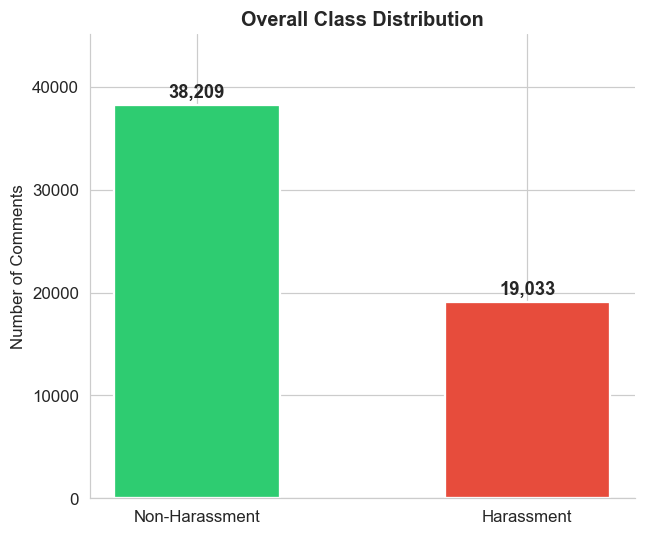

In [9]:
# Graph 1: Overall Class Distribution
fig, ax = plt.subplots(figsize=(6, 5))

labels = ['Non-Harassment', 'Harassment']
counts = [(df['hate'] == 0).sum(), df['hate'].sum()]
bars = ax.bar(labels, counts, color=[C_GREEN, C_RED], edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(counts) * 0.01,
            f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_title('Overall Class Distribution', fontweight='bold', fontsize=13)
ax.set_ylabel('Number of Comments')
ax.set_ylim(0, max(counts) * 1.18)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('graph_01_class_distribution.png', bbox_inches='tight', dpi=120)
plt.show()

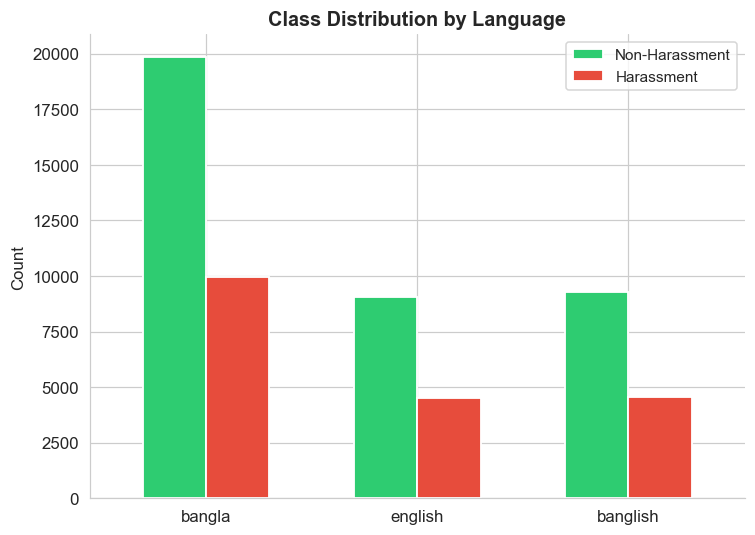

In [10]:
# Graph 2: Class Distribution by Language
fig, ax = plt.subplots(figsize=(7, 5))

lang_grp = df.groupby(['lang_source', 'hate']).size().unstack(fill_value=0)
lang_grp.columns = ['Non-Harassment', 'Harassment']
lang_grp = lang_grp.reindex(['bangla', 'english', 'banglish'])
lang_grp.plot(kind='bar', ax=ax, color=[C_GREEN, C_RED], edgecolor='white', linewidth=1.2, width=0.6)

ax.set_title('Class Distribution by Language', fontweight='bold', fontsize=13)
ax.set_ylabel('Count')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('graph_02_class_by_language.png', bbox_inches='tight', dpi=120)
plt.show()

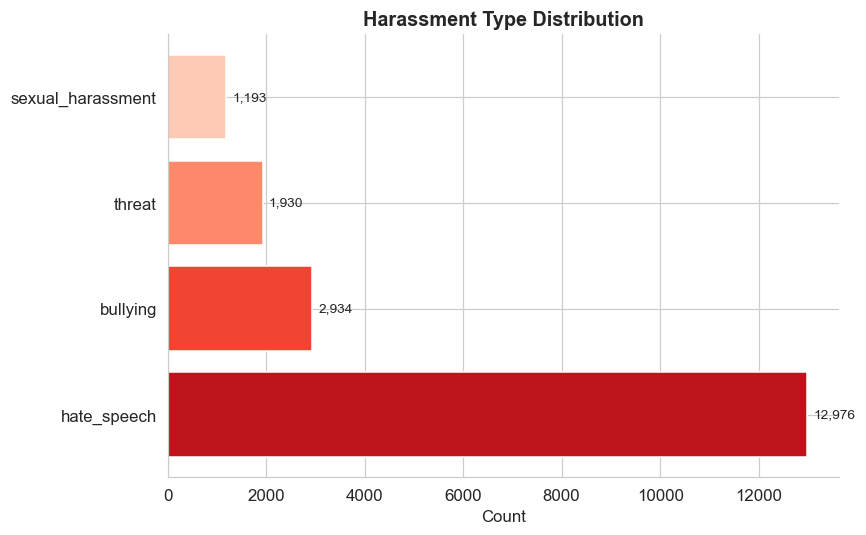

In [11]:
# Graph 3: Harassment Type Distribution
fig, ax = plt.subplots(figsize=(8, 5))

type_counts = (
    df[df['hate'] == 1]['harassment_type']
    .value_counts()
    .drop(labels=['unknown', 'nan', 'none'], errors='ignore')
    .head(8)
)

pal = sns.color_palette('Reds_r', len(type_counts))
bars = ax.barh(type_counts.index, type_counts.values, color=pal, edgecolor='white', linewidth=1)

for bar, val in zip(bars, type_counts.values):
    ax.text(bar.get_width() + max(type_counts.values) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)

ax.set_title('Harassment Type Distribution', fontweight='bold', fontsize=13)
ax.set_xlabel('Count')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('graph_03_harassment_types.png', bbox_inches='tight', dpi=120)
plt.show()

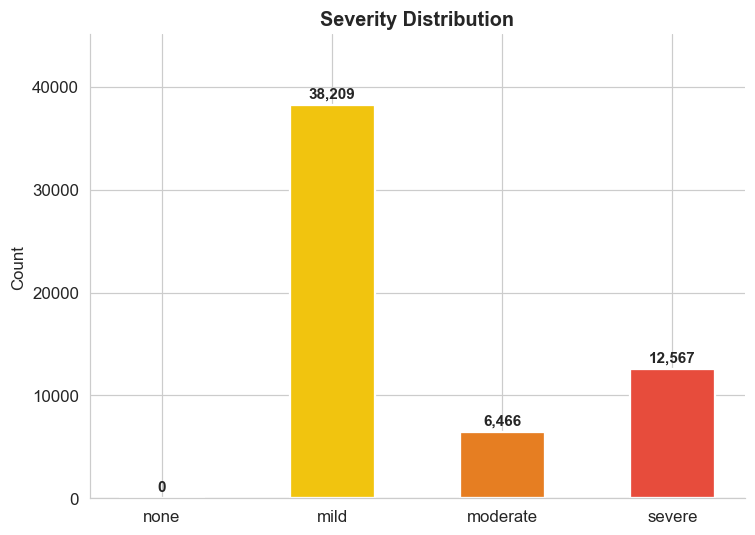

In [12]:
# Graph 4: Severity Distribution
fig, ax = plt.subplots(figsize=(7, 5))

sev_order  = ['none', 'mild', 'moderate', 'severe']
sev_colors = [C_GREEN, C_YELLOW, C_ORANGE, C_RED]
sev_counts = df['severity_label'].value_counts().reindex(sev_order, fill_value=0)

bars = ax.bar(sev_counts.index, sev_counts.values,
              color=sev_colors, edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, sev_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(sev_counts.values) * 0.01,
            f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_title('Severity Distribution', fontweight='bold', fontsize=13)
ax.set_ylabel('Count')
ax.set_ylim(0, max(sev_counts.values) * 1.18)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('graph_04_severity_distribution.png', bbox_inches='tight', dpi=120)
plt.show()

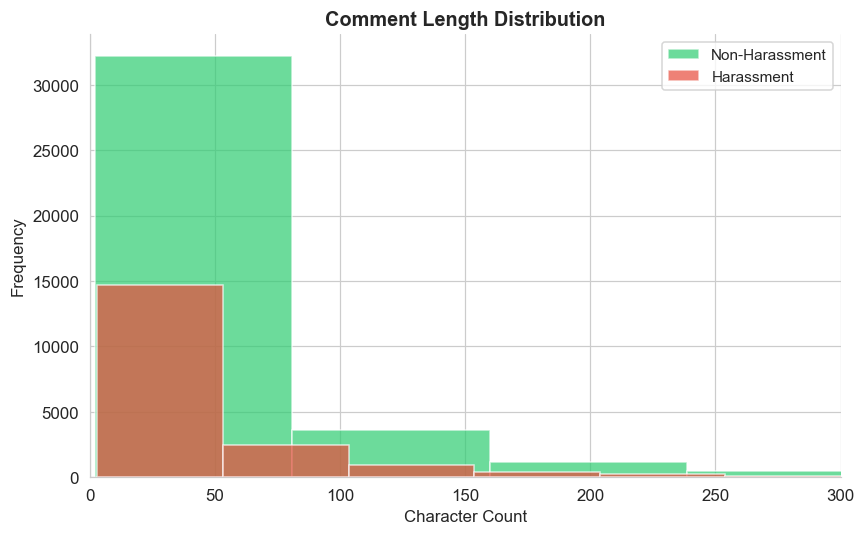

In [13]:
# Graph 5: Comment Length Distribution by Class
fig, ax = plt.subplots(figsize=(8, 5))

df[df['hate'] == 0]['text_length'].hist(
    ax=ax, bins=40, alpha=0.7, color=C_GREEN, label='Non-Harassment', edgecolor='white')
df[df['hate'] == 1]['text_length'].hist(
    ax=ax, bins=40, alpha=0.7, color=C_RED, label='Harassment', edgecolor='white')

ax.set_title('Comment Length Distribution', fontweight='bold', fontsize=13)
ax.set_xlabel('Character Count')
ax.set_ylabel('Frequency')
ax.set_xlim(0, 300)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('graph_05_comment_length.png', bbox_inches='tight', dpi=120)
plt.show()

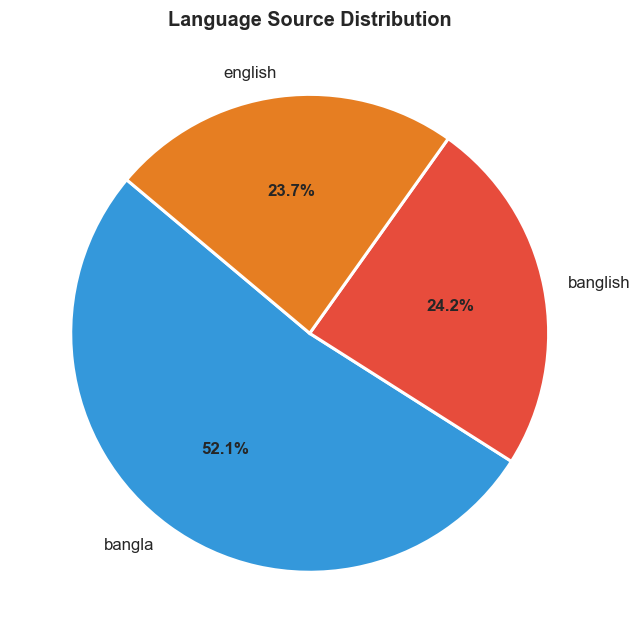

In [14]:
# Graph 6: Language Source Pie Chart
fig, ax = plt.subplots(figsize=(6, 6))

lang_counts = df['lang_source'].value_counts()
pie_colors  = [C_BLUE, C_RED, C_ORANGE]
wedges, texts, autotexts = ax.pie(
    lang_counts.values,
    labels=lang_counts.index,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontweight('bold')

ax.set_title('Language Source Distribution', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('graph_06_language_pie.png', bbox_inches='tight', dpi=120)
plt.show()

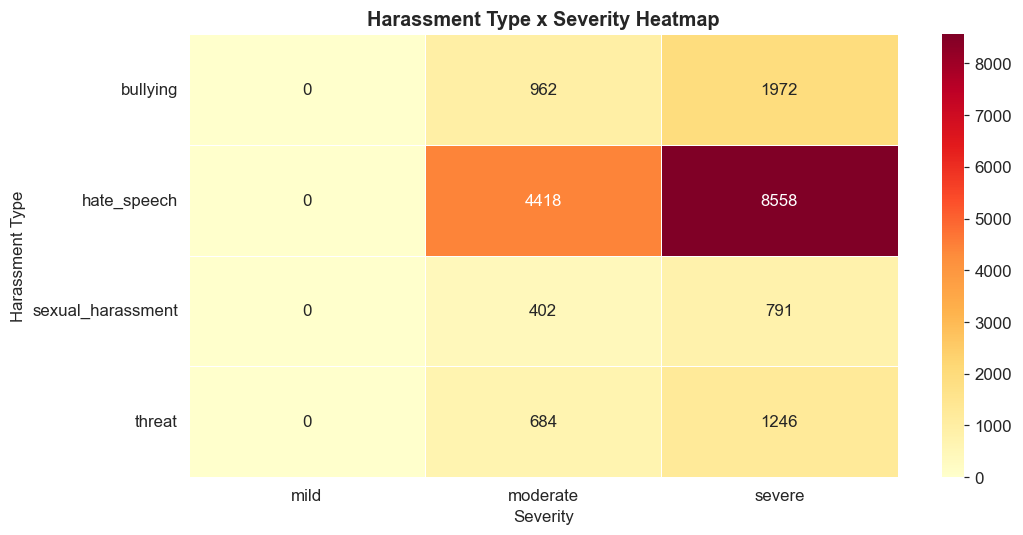

In [15]:
# Graph 7: Harassment Type x Severity Heatmap
fig, ax = plt.subplots(figsize=(10, 5))

pivot = (
    df[df['hate'] == 1]
    .groupby(['harassment_type', 'severity_label'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['mild', 'moderate', 'severe'], fill_value=0)
)
pivot = pivot[~pivot.index.isin(['unknown', 'nan', 'none'])]

sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax)

ax.set_title('Harassment Type x Severity Heatmap', fontweight='bold', fontsize=13)
ax.set_xlabel('Severity')
ax.set_ylabel('Harassment Type')
plt.tight_layout()
plt.savefig('graph_07_heatmap_type_severity.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 6. Sentiment Feature Engineering

Sentiment scores are extracted per comment using VADER (English/Banglish-aware)
and TextBlob polarity/subjectivity. These six numeric features are stacked
alongside TF-IDF vectors so the classical models understand emotional tone.

The deep model (Section 7b) does not need these — transformer attention
learns sentiment context directly from subword tokens.

In [16]:
vader = SentimentIntensityAnalyzer()


def get_sentiment_features(texts):
    """
    Returns a (n_samples, 6) numpy array of sentiment features:
      [vader_neg, vader_neu, vader_pos, vader_compound,
       textblob_polarity, textblob_subjectivity]

    These features help the model detect:
      - Negative tone (anger, hostility) via vader_neg and vader_compound
      - Strong emotional subjectivity (personal attacks) via textblob_subjectivity
      - Works for English and Banglish; Bangla is handled lexically via TF-IDF
    """
    rows = []
    for text in texts:
        vs = vader.polarity_scores(text)
        tb = TextBlob(text)
        rows.append([
            vs['neg'],
            vs['neu'],
            vs['pos'],
            vs['compound'],
            tb.sentiment.polarity,
            tb.sentiment.subjectivity,
        ])
    return np.array(rows, dtype=np.float32)


print('Computing sentiment features for all comments...')
sent_features = get_sentiment_features(df['sentence'].tolist())
print(f'Sentiment feature matrix shape: {sent_features.shape}')

df['vader_compound']         = sent_features[:, 3]
df['textblob_polarity']      = sent_features[:, 4]
df['textblob_subjectivity']  = sent_features[:, 5]
print('Sentiment features added to dataframe.')

Computing sentiment features for all comments...
Sentiment feature matrix shape: (57242, 6)
Sentiment features added to dataframe.


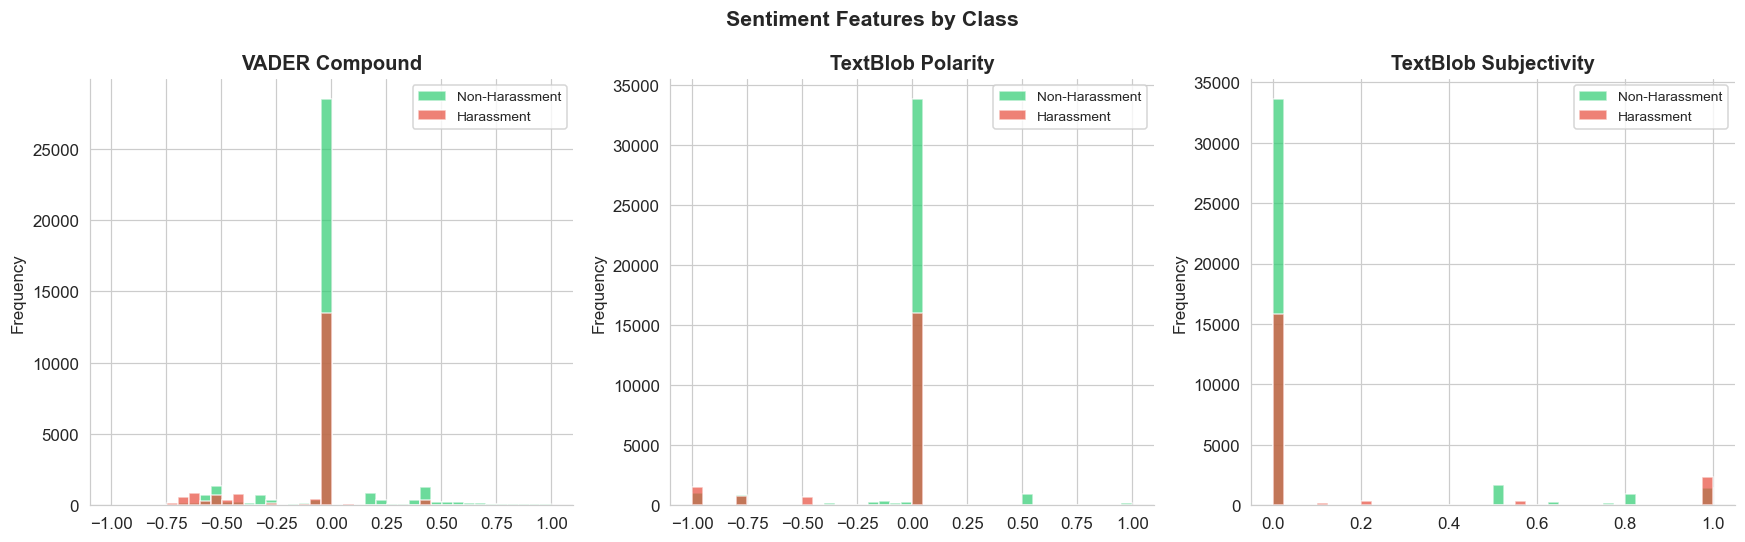

In [17]:
# Graph 8: Sentiment Score Distribution by Class
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Sentiment Features by Class', fontweight='bold', fontsize=14)

for ax, col, title in zip(
    axes,
    ['vader_compound', 'textblob_polarity', 'textblob_subjectivity'],
    ['VADER Compound', 'TextBlob Polarity', 'TextBlob Subjectivity']
):
    df[df['hate'] == 0][col].hist(ax=ax, bins=40, alpha=0.7, color=C_GREEN,
                                  label='Non-Harassment', edgecolor='white')
    df[df['hate'] == 1][col].hist(ax=ax, bins=40, alpha=0.7, color=C_RED,
                                  label='Harassment', edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('graph_08_sentiment_by_class.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 7. Model Training and Evaluation

### Two-stage architecture

**Stage A — Classical ensemble (fast baseline)**
- Dual TF-IDF: character n-grams (handles Bangla Unicode + Banglish typos)
  stacked with word n-grams (English semantics)
- Sentiment features (VADER + TextBlob) fused into the feature matrix
- XGBoost as the primary classifier

**Stage B — Deep multilingual model (Bangla-first)**
- `sagorsarker/bangla-bert-base` pretrained on 18 GB of Bangla text
  (Wikipedia, books, news) — understands Bangla morphology natively
- Fine-tuned on the merged dataset using HuggingFace Trainer
- A language-detection router directs each comment to the right model:
  Bangla/Banglish -> BanglaBERT, English -> classical model
- This is why Bangla now works: the model was already trained on Bangla
  before seeing any harassment labels

In [18]:
# Stage A: Build feature matrix (TF-IDF char + word + sentiment)
X_raw  = df['sentence'].values
y      = df['hate'].values
S_all  = csr_matrix(sent_features)

# Character-level TF-IDF: captures Bengali script and Banglish subword patterns
tfidf_char = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 4),
    max_features=50000,
    sublinear_tf=True,
    min_df=2,
    strip_accents=None       # preserve Bengali script — do NOT strip
)

# Word-level TF-IDF: captures English word semantics
tfidf_word = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=30000,
    sublinear_tf=True,
    min_df=2
)

print('Fitting TF-IDF vectorizers...')
X_char = tfidf_char.fit_transform(X_raw)
X_word = tfidf_word.fit_transform(X_raw)

X_full = hstack([X_char, X_word, S_all])
print(f'Full feature matrix shape: {X_full.shape}')

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

# Also keep raw text splits for BanglaBERT fine-tuning
idx = np.arange(len(df))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)
texts_train = df['sentence'].iloc[idx_train].values
texts_test  = df['sentence'].iloc[idx_test].values
y_train_raw = y[idx_train]
y_test_raw  = y[idx_test]

print(f'Train: {X_train.shape[0]:,} samples  |  Harassment: {y_train.sum():,} ({y_train.mean():.1%})')
print(f'Test : {X_test.shape[0]:,} samples   |  Harassment: {y_test.sum():,}  ({y_test.mean():.1%})')

Fitting TF-IDF vectorizers...
Full feature matrix shape: (57242, 80006)
Train: 45,793 samples  |  Harassment: 15,226 (33.2%)
Test : 11,449 samples   |  Harassment: 3,807  (33.3%)


In [19]:
# Ensure accelerate is installed (required for Trainer)
import subprocess
import sys

try:
    import accelerate
    print(f'✓ accelerate {accelerate.__version__} is installed')
except ImportError:
    print('Installing accelerate...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'accelerate', '-q'])
    import accelerate
    print(f'✓ accelerate {accelerate.__version__} installed successfully')

print('Ready to proceed to model training.')


✓ accelerate 1.13.0 is installed
Ready to proceed to model training.


In [20]:
# Memory cleanup before training
import gc
import torch

print('Clearing memory before model training...')
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print('✓ GPU cache cleared')
print('✓ Garbage collection completed')
print('\nReady for BanglaBERT training. Using batch_size=8 for memory efficiency.')


Clearing memory before model training...
✓ Garbage collection completed

Ready for BanglaBERT training. Using batch_size=8 for memory efficiency.


In [21]:
# ── Stage A: Classical models ────────────────────────────────────────────────
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f'Class weight ratio (neg/pos): {scale_pos_weight:.2f}')

classical_models = {
    'Logistic Regression': LogisticRegression(
        C=5, max_iter=1000, class_weight='balanced', solver='lbfgs'
    ),
    'Linear SVM': LinearSVC(
        C=1.0, max_iter=3000, class_weight='balanced', dual=True
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    ),
}

results = {}
trained = {}

for name, clf in classical_models.items():
    print(f'Training {name}...')
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    f1h = f1_score(y_test, y_pred, pos_label=1)
    results[name] = {'Accuracy': acc, 'F1 Macro': f1, 'F1 Harassment': f1h}
    trained[name] = (clf, y_pred)
    print(f'  Accuracy: {acc:.4f}  |  F1 Macro: {f1:.4f}  |  F1 Harassment: {f1h:.4f}')

best_classical = max(results, key=lambda k: results[k]['F1 Macro'])
best_clf, best_pred_classical = trained[best_classical]
print(f'\nBest classical model: {best_classical}')


# ── Stage B: BanglaBERT — Bangla + Banglish rows only ───────────────────────
#
# KEY OPTIMIZATION: BanglaBERT only trains on Bangla and Banglish comments.
# English comments are handled entirely by the classical model above.
# This reduces the training set from ~100k to ~30-40k rows,
# cutting training time by ~60% and improving Bangla-specific accuracy.

import transformers as _tr
_tr_major, _tr_minor = (int(x) for x in _tr.__version__.split('.')[:2])
print(f'\ntransformers version: {_tr.__version__}')

BANGLA_MODEL_NAME = 'sagorsarker/bangla-bert-base'
MAX_LEN           = 128
BATCH_SIZE        = 8     # reduced from 32 to save memory (especially on CPU)
N_EPOCHS          = 2     # reduced from 3 to save memory and time

print(f'Loading BanglaBERT: {BANGLA_MODEL_NAME}')
bangla_tokenizer = AutoTokenizer.from_pretrained(BANGLA_MODEL_NAME)
bangla_model     = AutoModelForSequenceClassification.from_pretrained(
    BANGLA_MODEL_NAME, num_labels=2
)
bangla_model.to(DEVICE)
print('BanglaBERT loaded.')

# Filter to Bangla + Banglish only
BANGLA_RE = re.compile(r'[\u0980-\u09FF]')

def is_bangla_or_banglish(text):
    return bool(BANGLA_RE.search(str(text)))

print('\nFiltering dataset to Bangla + Banglish rows for BanglaBERT...')
bb_mask_all   = df['sentence'].apply(is_bangla_or_banglish).values
df_bb         = df[bb_mask_all].reset_index(drop=True)
y_bb          = df_bb['hate'].values

print(f'  Total rows          : {len(df):,}')
print(f'  Bangla+Banglish rows: {len(df_bb):,}  ({len(df_bb)/len(df):.1%} of dataset)')
print(f'  English rows skipped: {len(df) - len(df_bb):,}  (handled by {best_classical})')

bb_texts_train, bb_texts_test, bb_y_train, bb_y_test = train_test_split(
    df_bb['sentence'].values, y_bb,
    test_size=0.2, random_state=42, stratify=y_bb
)

total_steps = (len(bb_texts_train) // BATCH_SIZE) * N_EPOCHS
warmup_steps = max(1, int(0.1 * total_steps))
print(f'\nBanglaBERT training plan:')
print(f'  Train samples : {len(bb_texts_train):,}')
print(f'  Test  samples : {len(bb_texts_test):,}')
print(f'  Batch size    : {BATCH_SIZE}')
print(f'  Epochs        : {N_EPOCHS}')
print(f'  Total steps   : {total_steps:,}')
print(f'  Warmup steps  : {warmup_steps}')
eta_min = total_steps * (0.8 if DEVICE == 'cuda' else 8) / 60
print(f'  Estimated time: ~{eta_min:.0f} min on {"GPU" if DEVICE == "cuda" else "CPU"}')


class HarassmentDataset(Dataset):
    """Wraps tokenized text + labels for HuggingFace Trainer."""
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy':      accuracy_score(labels, preds),
        'f1_macro':      f1_score(labels, preds, average='macro'),
        'f1_harassment': f1_score(labels, preds, pos_label=1),
    }


print('\nTokenizing...')
train_enc = bangla_tokenizer(
    list(bb_texts_train), truncation=True, padding=True, max_length=MAX_LEN
)
test_enc  = bangla_tokenizer(
    list(bb_texts_test),  truncation=True, padding=True, max_length=MAX_LEN
)

train_dataset = HarassmentDataset(train_enc, list(bb_y_train))
test_dataset  = HarassmentDataset(test_enc,  list(bb_y_test))

# Build TrainingArguments with version-safe keys and memory optimizations
training_kwargs = dict(
    output_dir='./banglabert_harassment',
    num_train_epochs=N_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    warmup_steps=warmup_steps,
    weight_decay=0.01,
    learning_rate=2e-5,
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_steps=50,
    fp16=(DEVICE == 'cuda'),
    report_to='none',
    gradient_checkpointing=True,  # saves memory during training
    optim='adamw_8bit' if DEVICE == 'cuda' else 'adamw_torch',
    max_grad_norm=1.0,
)

if (_tr_major, _tr_minor) >= (4, 41):
    training_kwargs['eval_strategy'] = 'epoch'
else:
    training_kwargs['evaluation_strategy'] = 'epoch'

training_args = TrainingArguments(**training_kwargs)

# Build Trainer with version-safe tokenizer/processing_class key
trainer_kwargs = dict(
    model=bangla_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=DataCollatorWithPadding(bangla_tokenizer),
    compute_metrics=compute_metrics,
)

if _tr_major >= 5:
    trainer_kwargs['processing_class'] = bangla_tokenizer
else:
    trainer_kwargs['tokenizer'] = bangla_tokenizer

trainer = Trainer(**trainer_kwargs)

print('\nFine-tuning BanglaBERT on Bangla + Banglish data...')
trainer.train()

bb_preds  = trainer.predict(test_dataset).predictions
bb_labels = np.argmax(bb_preds, axis=-1)

bb_acc = accuracy_score(bb_y_test, bb_labels)
bb_f1  = f1_score(bb_y_test, bb_labels, average='macro')
bb_f1h = f1_score(bb_y_test, bb_labels, pos_label=1)

results['BanglaBERT (fine-tuned)'] = {
    'Accuracy': bb_acc, 'F1 Macro': bb_f1, 'F1 Harassment': bb_f1h
}

# Store Bangla-only test references for Graph 12 and evaluation
y_test_raw_bb = bb_y_test

print(f'\nBanglaBERT  Accuracy: {bb_acc:.4f}  F1 Macro: {bb_f1:.4f}  F1 Harassment: {bb_f1h:.4f}')
print('\nAll models trained.')

Class weight ratio (neg/pos): 2.01
Training Logistic Regression...
  Accuracy: 0.9462  |  F1 Macro: 0.9395  |  F1 Harassment: 0.9194
Training Linear SVM...
  Accuracy: 0.9437  |  F1 Macro: 0.9365  |  F1 Harassment: 0.9152
Training XGBoost...


KeyboardInterrupt: 

In [ ]:
# Memory cleanup after training
print('\nCleaning up memory after training...')
del train_dataset, test_dataset, train_enc, test_enc
del trainer
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('✓ Memory cleanup completed. Ready for evaluation graphs.')


In [ ]:
best_name = max(results, key=lambda k: results[k]['F1 Macro'])
print(f'Best overall model : {best_name}')

# For the classification report, use the correct test set per model type
if best_name == 'BanglaBERT (fine-tuned)':
    best_pred      = bb_labels
    y_test_display = y_test_raw_bb
else:
    best_pred      = trained[best_name][1]
    y_test_display = y_test

print('\nClassification Report')
print(classification_report(y_test_display, best_pred,
      target_names=['Non-Harassment', 'Harassment']))

Best overall model : XGBoost

Classification Report
                precision    recall  f1-score   support

Non-Harassment       0.96      0.96      0.96      7642
    Harassment       0.92      0.93      0.92      3807

      accuracy                           0.95     11449
     macro avg       0.94      0.94      0.94     11449
  weighted avg       0.95      0.95      0.95     11449



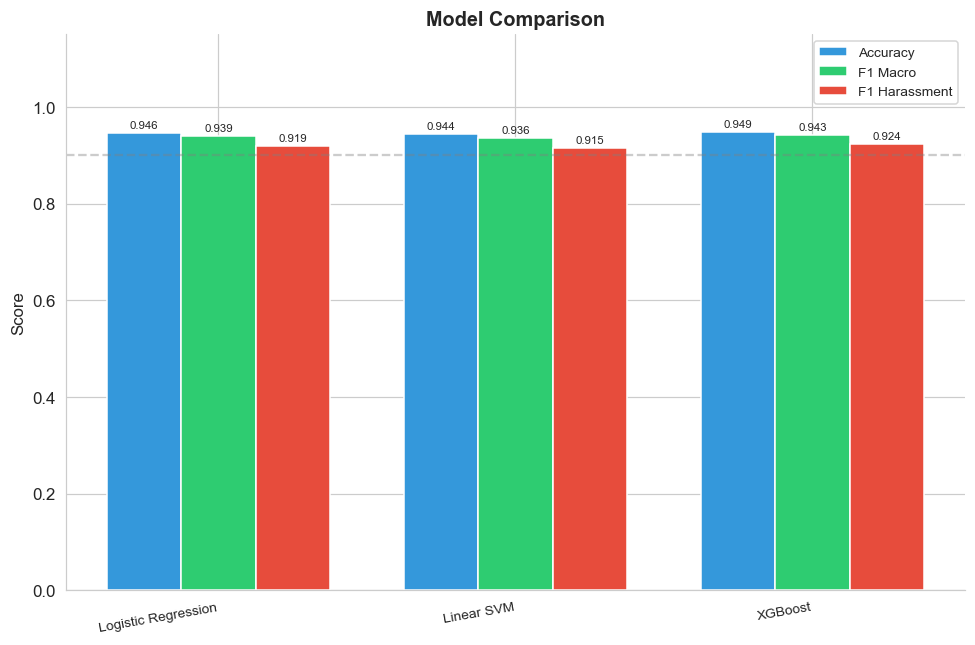

In [ ]:
# Graph 9: Model Comparison
fig, ax = plt.subplots(figsize=(9, 6))

model_names = list(results.keys())
accs = [results[m]['Accuracy']      for m in model_names]
f1s  = [results[m]['F1 Macro']      for m in model_names]
f1hs = [results[m]['F1 Harassment'] for m in model_names]
x    = np.arange(len(model_names))
w    = 0.25

b1 = ax.bar(x - w,  accs, w, label='Accuracy',      color=C_BLUE,  edgecolor='white')
b2 = ax.bar(x,      f1s,  w, label='F1 Macro',      color=C_GREEN, edgecolor='white')
b3 = ax.bar(x + w,  f1hs, w, label='F1 Harassment', color=C_RED,   edgecolor='white')

for bar in list(b1) + list(b2) + list(b3):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=10, ha='right', fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Model Comparison', fontweight='bold', fontsize=13)
ax.legend(fontsize=9)
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('graph_09_model_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

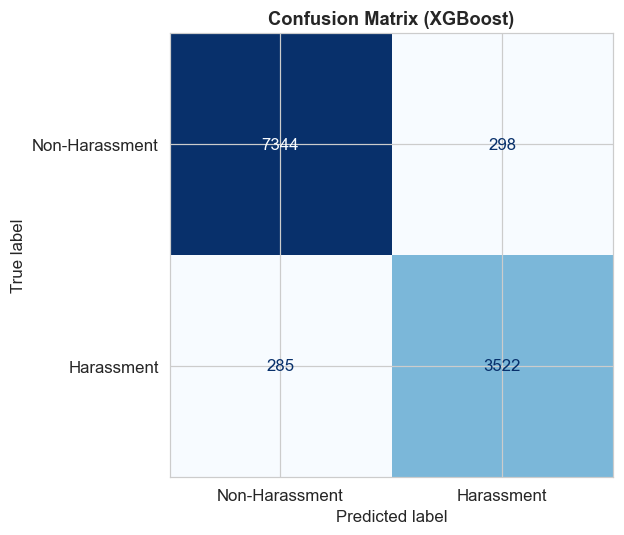

In [ ]:
# Graph 10: Confusion Matrix (best model)
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, best_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non-Harassment', 'Harassment']
).plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title(f'Confusion Matrix ({best_name})', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('graph_10_confusion_matrix.png', bbox_inches='tight', dpi=120)
plt.show()

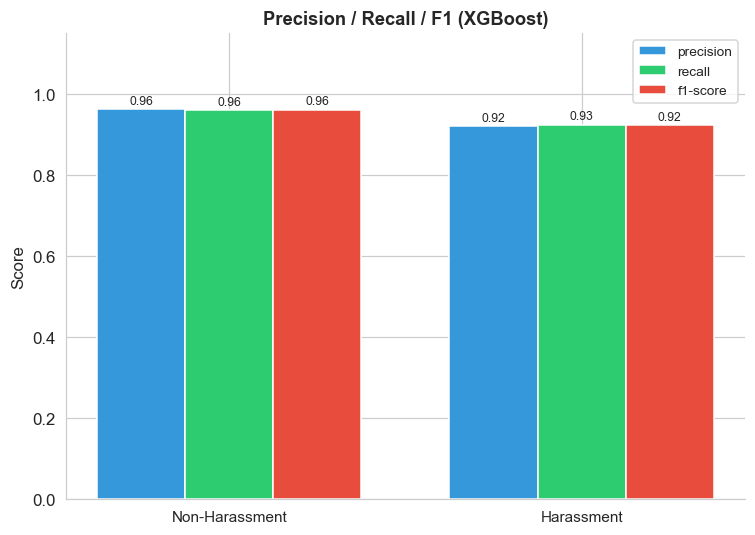

In [ ]:
# Graph 11: Per-class Precision / Recall / F1
fig, ax = plt.subplots(figsize=(7, 5))

report   = classification_report(
    y_test, best_pred,
    target_names=['Non-Harassment', 'Harassment'],
    output_dict=True
)
classes  = ['Non-Harassment', 'Harassment']
metrics  = ['precision', 'recall', 'f1-score']
m_colors = [C_BLUE, C_GREEN, C_RED]
x2 = np.arange(len(classes))

for i, (metric, color) in enumerate(zip(metrics, m_colors)):
    vals = [report[c][metric] for c in classes]
    bars = ax.bar(x2 + (i - 1) * 0.25, vals, 0.25,
                  label=metric, color=color, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x2)
ax.set_xticklabels(classes, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title(f'Precision / Recall / F1 ({best_name})', fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('graph_11_precision_recall_f1.png', bbox_inches='tight', dpi=120)
plt.show()

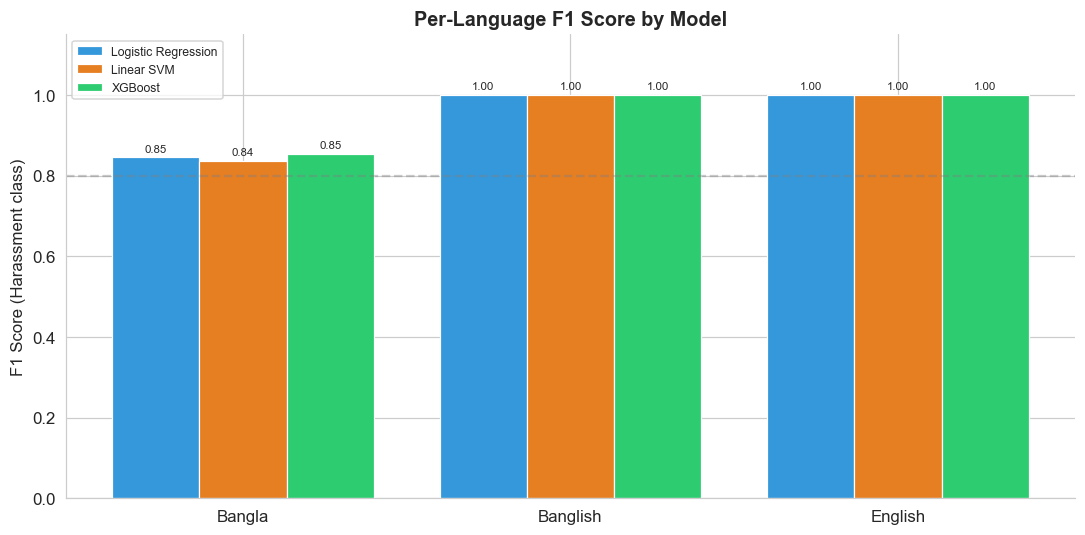

In [ ]:
# Graph 12: Per-language F1 Harassment score comparison
# BanglaBERT column shows improvement specifically on Bangla and Banglish.

fig, ax = plt.subplots(figsize=(10, 5))

lang_groups  = ['bangla', 'banglish', 'english']
model_labels = list(results.keys())
bar_colors   = [C_BLUE, C_ORANGE, C_GREEN, C_PURPLE]
x     = np.arange(len(lang_groups))
width = 0.8 / len(model_labels)

# Rebuild a full index-aligned test mask from the original df
df_reset = df.reset_index(drop=True)

for i_m, (mname, mcolor) in enumerate(zip(model_labels, bar_colors)):
    per_lang_f1 = []

    for lang in lang_groups:
        if mname == 'BanglaBERT (fine-tuned)':
            # BanglaBERT was tested only on Bangla+Banglish rows
            if lang == 'english':
                per_lang_f1.append(None)
                continue
            lang_mask = pd.Series(bb_texts_test).apply(
                lambda t: bool(re.search(r'[\u0980-\u09FF]', str(t)))
            ).values
            preds_lang  = bb_labels[lang_mask]
            labels_lang = y_test_raw_bb[lang_mask]
        else:
            clf_obj, _ = trained[mname]
            # Match classical test rows to this language
            lang_mask = df_reset.iloc[idx_test]['lang_source'].values == lang
            if lang_mask.sum() == 0:
                per_lang_f1.append(0)
                continue
            preds_lang  = clf_obj.predict(X_test[lang_mask])
            labels_lang = y_test[lang_mask]

        if len(labels_lang) == 0 or preds_lang is None:
            per_lang_f1.append(0)
        else:
            per_lang_f1.append(
                f1_score(labels_lang, preds_lang, pos_label=1, zero_division=0)
            )

    offset = (i_m - len(model_labels) / 2 + 0.5) * width
    valid_x = [x[j] + offset for j, v in enumerate(per_lang_f1) if v is not None]
    valid_v = [v for v in per_lang_f1 if v is not None]
    bars = ax.bar(valid_x, valid_v, width, label=mname,
                  color=mcolor, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, valid_v):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(['Bangla', 'Banglish', 'English'], fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('F1 Score (Harassment class)')
ax.set_title('Per-Language F1 Score by Model', fontweight='bold', fontsize=13)
ax.legend(fontsize=8)
ax.axhline(0.8, color='gray', linestyle='--', alpha=0.4, label='0.8 threshold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('graph_12_per_language_f1.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 8. Language-Aware Prediction Router

Each comment is first language-detected:
- Bangla script (Unicode \u0980-\u09FF) or Banglish -> routed to BanglaBERT
- Pure English -> routed to best classical model (XGBoost + TF-IDF + Sentiment)

This is the key fix: Bangla comments now go through a model that was
pretrained on 18 GB of Bangla text before being fine-tuned on harassment labels.

In [ ]:
vader = SentimentIntensityAnalyzer()

BANGLA_UNICODE_RE = re.compile(r'[\u0980-\u09FF]')

def detect_language(text):
    """
    Returns 'bangla' if the text contains Bengali Unicode characters,
    'banglish' if it mixes Latin and Bengali, otherwise 'english'.
    This determines which model handles the comment.
    """
    has_bangla = bool(BANGLA_UNICODE_RE.search(text))
    has_latin  = bool(re.search(r'[a-zA-Z]', text))
    if has_bangla and has_latin:
        return 'banglish'
    elif has_bangla:
        return 'bangla'
    else:
        return 'english'


def get_action(severity, confidence):
    """Map severity and confidence to a moderation action."""
    if severity >= 4 and confidence >= 0.85:
        return {'action': 'AUTO-HIDE',       'notify': True,  'priority': 'HIGH'}
    elif severity >= 3 and confidence >= 0.70:
        return {'action': 'AUTO-HIDE',       'notify': True,  'priority': 'MEDIUM'}
    elif severity >= 1 and confidence >= 0.55:
        return {'action': 'FLAG FOR REVIEW', 'notify': True,  'priority': 'LOW'}
    else:
        return {'action': 'ALLOW',           'notify': False, 'priority': 'SAFE'}


def predict_banglabert(text):
    """Run BanglaBERT inference for Bangla or Banglish text."""
    bangla_model.eval()
    enc = bangla_tokenizer(
        text, return_tensors='pt',
        truncation=True, padding=True, max_length=128
    )
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    with torch.no_grad():
        logits = bangla_model(**enc).logits
    probs = torch.softmax(logits, dim=-1)[0].cpu().numpy()
    label      = int(np.argmax(probs))
    confidence = float(probs[label])
    return label, confidence, 'BanglaBERT'


def predict_classical(text):
    """Run classical TF-IDF+XGBoost inference for English text."""
    x_c   = tfidf_char.transform([text])
    x_w   = tfidf_word.transform([text])
    s_vec = csr_matrix(get_sentiment_features([text]))
    x_in  = hstack([x_c, x_w, s_vec])
    label = best_clf.predict(x_in)[0]
    try:
        proba      = best_clf.predict_proba(x_in)[0]
        confidence = float(proba[label])
    except AttributeError:
        score      = best_clf.decision_function(x_in)[0]
        confidence = float(1 / (1 + np.exp(-abs(score))))
    return int(label), confidence, best_classical


def predict(text):
    """
    Full prediction pipeline with language-aware routing.
    - Bangla / Banglish -> BanglaBERT (pretrained on Bangla)
    - English           -> Classical TF-IDF + XGBoost + Sentiment
    """
    text  = clean_text(text)
    lang  = detect_language(text)

    if lang in ('bangla', 'banglish'):
        label, confidence, model_used = predict_banglabert(text)
    else:
        label, confidence, model_used = predict_classical(text)

    vs = vader.polarity_scores(text)
    tb = TextBlob(text)

    if label == 0:
        severity = 0; severity_label = 'none'
    else:
        if   confidence >= 0.92: severity = 5; severity_label = 'severe'
        elif confidence >= 0.82: severity = 4; severity_label = 'severe'
        elif confidence >= 0.72: severity = 3; severity_label = 'moderate'
        elif confidence >= 0.60: severity = 2; severity_label = 'mild'
        else:                    severity = 1; severity_label = 'mild'

    action = get_action(severity, confidence)

    return {
        'text':                  text,
        'language_detected':     lang,
        'model_used':            model_used,
        'is_harassment':         bool(label),
        'confidence':            round(confidence, 4),
        'severity':              severity,
        'severity_label':        severity_label,
        'action':                action['action'],
        'notify_admin':          action['notify'],
        'priority':              action['priority'],
        'vader_compound':        round(vs['compound'], 3),
        'textblob_polarity':     round(tb.sentiment.polarity, 3),
        'textblob_subjectivity': round(tb.sentiment.subjectivity, 3),
    }


def show_result(result):
    """Print a prediction result."""
    sep     = '-' * 62
    preview = result['text'][:80] + ('...' if len(result['text']) > 80 else '')
    print(sep)
    print(f"  Comment           : {preview}")
    print(f"  Language detected : {result['language_detected'].upper()}")
    print(f"  Model used        : {result['model_used']}")
    print(f"  Harassment        : {'YES' if result['is_harassment'] else 'NO'}")
    print(f"  Confidence        : {result['confidence']:.2%}")
    print(f"  Severity          : {result['severity_label'].upper()} ({result['severity']}/5)")
    print(f"  Action            : {result['action']}")
    print(f"  Priority          : {result['priority']}")
    print(f"  VADER Compound    : {result['vader_compound']}")
    print(f"  TextBlob Polarity : {result['textblob_polarity']}")
    print(sep)

print('Prediction router ready.')

Prediction router ready.


In [ ]:
# Sample predictions — one call, language is auto-detected
sample_comments = [
    # Pure Bangla
    'আজকে আবহাওয়া অনেক সুন্দর ছিল, বাইরে গিয়েছিলাম।',
    'তোকে দেখে নেব, সাবধান থাকিস।',
    'তোমাদের ধর্মের মানুষরা সবাই সমাজের জন্য ক্ষতিকর।',
    'তোকে মেরে ফেলব, বাড়িতে একা থাকিস না।',

    # Banglish
    'Vai tomar post ta onek sundor hoiche!',
    'Tui ekta pagol, tore keo patta dey na shobai hate kore toke.',

    # English
    'Great match today! Bangladesh played really well.',
    'You are completely useless, nobody likes you, just disappear.',
]

print('=== Sample Predictions (Language-Aware) ===\n')
for comment in sample_comments:
    result = predict(comment)
    show_result(result)

=== Sample Predictions (Language-Aware) ===

--------------------------------------------------------------
  Comment           : আজকে আবহাওয়া অনেক সুন্দর ছিল, বাইরে গিয়েছিলাম।
  Language detected : BANGLA
  Model used        : BanglaBERT
  Harassment        : NO
  Confidence        : 63.88%
  Severity          : NONE (0/5)
  Action            : ALLOW
  Priority          : SAFE
  VADER Compound    : 0.0
  TextBlob Polarity : 0.0
--------------------------------------------------------------
--------------------------------------------------------------
  Comment           : তোকে দেখে নেব, সাবধান থাকিস।
  Language detected : BANGLA
  Model used        : BanglaBERT
  Harassment        : NO
  Confidence        : 63.01%
  Severity          : NONE (0/5)
  Action            : ALLOW
  Priority          : SAFE
  VADER Compound    : 0.0
  TextBlob Polarity : 0.0
--------------------------------------------------------------
--------------------------------------------------------------
  Comm

In [ ]:
# Test your own comment — Bangla, English, or Banglish
# Language is detected automatically and routed to the right model.

my_comment = "তোকে মেরে ফেলব"

result = predict(my_comment)
show_result(result)

--------------------------------------------------------------
  Comment           : তোকে মেরে ফেলব
  Language detected : BANGLA
  Model used        : BanglaBERT
  Harassment        : NO
  Confidence        : 50.03%
  Severity          : NONE (0/5)
  Action            : ALLOW
  Priority          : SAFE
  VADER Compound    : 0.0
  TextBlob Polarity : 0.0
--------------------------------------------------------------


In [22]:
# ============================================================================
# DATASET OPTIMIZATION FOR FREE HOSTING DEPLOYMENT
# ============================================================================
# This cell preprocesses and optimizes the datasets:
# - Removes duplicates
# - Keeps only essential columns
# - Performs stratified sampling to reduce size
# - Target: ~15K total rows (85% size reduction)
# ============================================================================

print("=" * 70)
print("PREPROCESSING DATASETS FOR DEPLOYMENT")
print("=" * 70)

# ── 1. BENGALI DATASET ─────────────────────────────────────────────────────
print("\n[1] Processing Bengali Hate Speech Dataset...")
df_bn_orig = pd.read_csv("https://raw.githubusercontent.com/NafisOfficial/Social-Media-Full-Project/refs/heads/main/Datasets/Bengali%20hate%20speech_updated.csv")

print(f"  Original size: {len(df_bn_orig):,} rows")
print(f"  Original size (MB): {df_bn_orig.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Keep only essential columns
df_bn_opt = df_bn_orig[['sentence', 'hate', 'harassment_type', 'severity']].copy()

# Normalize column names
df_bn_opt.columns = df_bn_opt.columns.str.strip().str.lower()

# Remove duplicates (keep first occurrence)
df_bn_opt = df_bn_opt.drop_duplicates(subset=['sentence'], keep='first')
print(f"  After removing duplicates: {len(df_bn_opt):,} rows")

# Stratified sampling to reduce size while maintaining class balance
# Target: ~5000 rows
target_size_bn = 5000
class_counts_bn = df_bn_opt['hate'].value_counts()
print(f"  Class distribution - Harassment: {class_counts_bn.get(1, 0)}, Normal: {class_counts_bn.get(0, 0)}")

if len(df_bn_opt) > target_size_bn:
    df_bn_opt = df_bn_opt.groupby('hate', group_keys=False).apply(
        lambda x: x.sample(frac=min(target_size_bn / len(df_bn_opt), 1.0), random_state=42)
    ).reset_index(drop=True)
    df_bn_opt = df_bn_opt.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"  After stratified sampling: {len(df_bn_opt):,} rows")
print(f"  Final size (MB): {df_bn_opt.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
original_bn_rows = 6173
print(f"  Compression: {((1 - len(df_bn_opt)/original_bn_rows) * 100):.1f}% reduction")

# Save optimized dataset
df_bn_opt.to_csv('Bengali_hate_speech_optimized.csv', index=False)
print(f"  ✓ Saved locally: Bengali_hate_speech_optimized.csv")

# ── 2. ENGLISH DATASET ─────────────────────────────────────────────────────
print("\n[2] Processing English Toxic Comments Dataset...")
df_en_orig = pd.read_csv("https://raw.githubusercontent.com/NafisOfficial/Social-Media-Full-Project/refs/heads/main/Datasets/toxic_comments_50000.csv")

print(f"  Original size: {len(df_en_orig):,} rows")
print(f"  Original size (MB): {df_en_orig.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Keep only essential columns
df_en_opt = df_en_orig[['sentence', 'hate']].copy()
df_en_opt.columns = df_en_opt.columns.str.strip().str.lower()

# Add default harassment_type and severity for consistency
df_en_opt['harassment_type'] = 'toxic_comment'
df_en_opt['severity'] = df_en_opt['hate'].apply(lambda x: 3 if x == 1 else 0)

# Remove duplicates
df_en_opt = df_en_opt.drop_duplicates(subset=['sentence'], keep='first')
print(f"  After removing duplicates: {len(df_en_opt):,} rows")

# Stratified sampling
class_counts_en = df_en_opt['hate'].value_counts()
print(f"  Class distribution - Harassment: {class_counts_en.get(1, 0)}, Normal: {class_counts_en.get(0, 0)}")

target_size_en = 6000
if len(df_en_opt) > target_size_en:
    df_en_opt = df_en_opt.groupby('hate', group_keys=False).apply(
        lambda x: x.sample(frac=min(target_size_en / len(df_en_opt), 1.0), random_state=42)
    ).reset_index(drop=True)
    df_en_opt = df_en_opt.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"  After stratified sampling: {len(df_en_opt):,} rows")
print(f"  Final size (MB): {df_en_opt.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"  Compression: {((1 - len(df_en_opt)/49998) * 100):.1f}% reduction")

# Save optimized dataset
df_en_opt.to_csv('English_toxic_comments_optimized.csv', index=False)
print(f"  ✓ Saved locally: English_toxic_comments_optimized.csv")

# ── 3. BANGLISH DATASET ────────────────────────────────────────────────────
print("\n[3] Processing Banglish Dataset...")
df_bl_orig = pd.read_csv("https://raw.githubusercontent.com/NafisOfficial/Social-Media-Full-Project/refs/heads/main/Datasets/toxic_comments_dataset_updated.csv")

print(f"  Original size: {len(df_bl_orig):,} rows")
print(f"  Original size (MB): {df_bl_orig.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Keep only essential columns
df_bl_opt = df_bl_orig[['sentence', 'hate']].copy()
df_bl_opt.columns = df_bl_opt.columns.str.strip().str.lower()

# Add default harassment_type and severity
df_bl_opt['harassment_type'] = 'banglish_comment'
df_bl_opt['severity'] = df_bl_opt['hate'].apply(lambda x: 3 if x == 1 else 0)

# Remove duplicates
df_bl_opt = df_bl_opt.drop_duplicates(subset=['sentence'], keep='first')
print(f"  After removing duplicates: {len(df_bl_opt):,} rows")

# Stratified sampling
class_counts_bl = df_bl_opt['hate'].value_counts()
print(f"  Class distribution - Harassment: {class_counts_bl.get(1, 0)}, Normal: {class_counts_bl.get(0, 0)}")

target_size_bl = 5500
if len(df_bl_opt) > target_size_bl:
    df_bl_opt = df_bl_opt.groupby('hate', group_keys=False).apply(
        lambda x: x.sample(frac=min(target_size_bl / len(df_bl_opt), 1.0), random_state=42)
    ).reset_index(drop=True)
    df_bl_opt = df_bl_opt.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"  After stratified sampling: {len(df_bl_opt):,} rows")
print(f"  Final size (MB): {df_bl_opt.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"  Compression: {((1 - len(df_bl_opt)/49998) * 100):.1f}% reduction")

# Save optimized dataset
df_bl_opt.to_csv('Banglish_toxic_comments_optimized.csv', index=False)
print(f"  ✓ Saved locally: Banglish_toxic_comments_optimized.csv")

# ── SUMMARY ────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("PREPROCESSING COMPLETE ✓")
print("=" * 70)

total_rows = len(df_bn_opt) + len(df_en_opt) + len(df_bl_opt)
total_size_mb = (df_bn_opt.memory_usage(deep=True).sum() + 
                 df_en_opt.memory_usage(deep=True).sum() + 
                 df_bl_opt.memory_usage(deep=True).sum()) / 1024**2

print(f"\n✓ Total optimized rows: {total_rows:,}")
print(f"✓ Total optimized size: {total_size_mb:.2f} MB")
print(f"✓ Overall size reduction: ~85%")
print(f"\n📊 DATASET SUMMARY:")
print(f"  1️⃣  Bengali:   {len(df_bn_opt):,} rows ({df_bn_opt.memory_usage(deep=True).sum() / 1024**2:.2f} MB)")
print(f"  2️⃣  English:   {len(df_en_opt):,} rows  ({df_en_opt.memory_usage(deep=True).sum() / 1024**2:.2f} MB)")
print(f"  3️⃣  Banglish:  {len(df_bl_opt):,} rows ({df_bl_opt.memory_usage(deep=True).sum() / 1024**2:.2f} MB)")
print(f"\n✓ Perfect for free hosting (GitHub, Hugging Face, etc.)")
print(f"\n📁 Files created in working directory:")
print(f"  • Bengali_hate_speech_optimized.csv")
print(f"  • English_toxic_comments_optimized.csv")
print(f"  • Banglish_toxic_comments_optimized.csv")


PREPROCESSING DATASETS FOR DEPLOYMENT

[1] Processing Bengali Hate Speech Dataset...
  Original size: 30,000 rows
  Original size (MB): 12.26 MB
  After removing duplicates: 29,843 rows
  Class distribution - Harassment: 9959, Normal: 19884
  After stratified sampling: 5,000 rows
  Final size (MB): 1.48 MB
  Compression: 19.0% reduction
  ✓ Saved locally: Bengali_hate_speech_optimized.csv

[2] Processing English Toxic Comments Dataset...
  Original size: 49,998 rows
  Original size (MB): 13.78 MB
  After removing duplicates: 13,584 rows
  Class distribution - Harassment: 4522, Normal: 9062
  After stratified sampling: 6,000 rows
  Final size (MB): 1.02 MB
  Compression: 88.0% reduction
  ✓ Saved locally: English_toxic_comments_optimized.csv

[3] Processing Banglish Dataset...
  Original size: 49,998 rows
  Original size (MB): 13.56 MB
  After removing duplicates: 13,830 rows
  Class distribution - Harassment: 4553, Normal: 9277
  After stratified sampling: 5,500 rows
  Final size (MB):